# Deep Learning Model Selection


## Setup


In [1]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

X_train_s   = np.load("../data/X_train.npy")
X_val_s     = np.load("../data/X_val.npy")
X_test_s    = np.load("../data/X_test.npy")
y_train_arr = np.load("../data/y_train.npy")
y_val_arr   = np.load("../data/y_val.npy")
y_test_arr  = np.load("../data/y_test.npy")

n_features = X_train_s.shape[1]
print("Successfully loaded data.")

Successfully loaded data.


## Model Architectures


In [2]:
shallow = Sequential()
shallow.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=n_features))
shallow.add(Dense(units=1, activation='sigmoid'))

medium = Sequential()
medium.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=n_features))
medium.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
medium.add(Dense(units=1, activation='sigmoid'))

deep = Sequential()
deep.add(Dense(units=6, kernel_initializer='uniform', activation='relu', input_dim=n_features))
deep.add(Dropout(0.1))
deep.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
deep.add(Dropout(0.1))
deep.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
deep.add(Dense(units=1, activation='sigmoid'))

## Training

All models are compiled with Adam optimiser and binary cross-entropy loss.  
Each is trained for 100 epochs with a batch size of 10.


In [3]:
def compile_and_train(model):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model.fit(X_train_s, y_train_arr,
                     batch_size=10,
                     epochs=100,
                     verbose=0)

histories = {}
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    print(f"Training {name}...", end=" ")
    histories[name] = compile_and_train(model)
    print("Done")

Training Shallow... 

2026-05-12 03:50:19.858170: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Done
Training Medium... Done
Training Deep... Done


## Training Curves


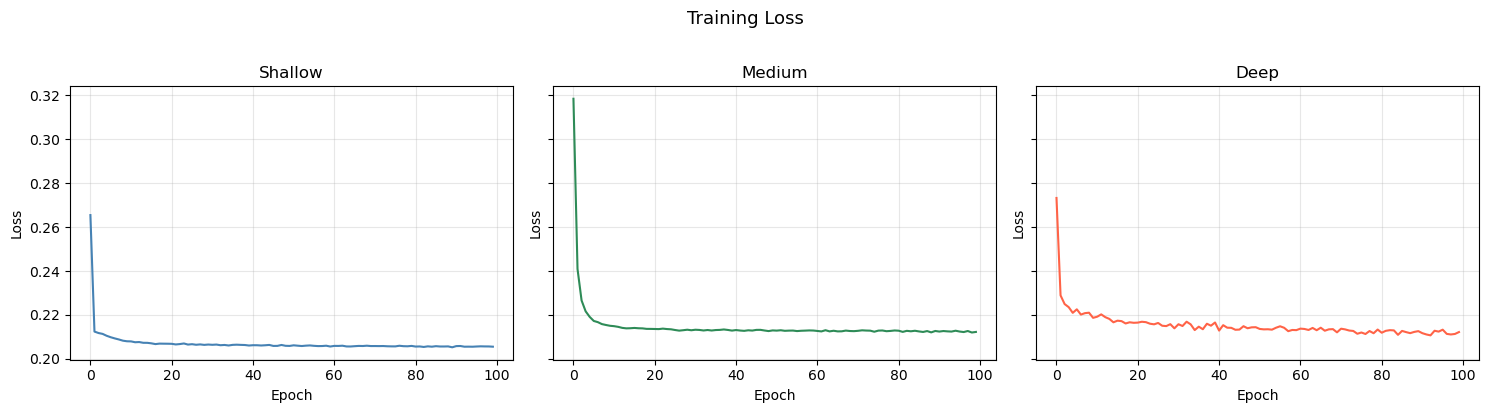

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
configs = [("Shallow", "steelblue"), ("Medium", "seagreen"), ("Deep", "tomato")]
for ax, (name, color) in zip(axes, configs):
    h = histories[name].history
    ax.plot(h["loss"], color=color)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
plt.suptitle("Training Loss", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Evaluation


In [5]:
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    y_pred = model.predict(X_val_s)
    y_pred = (y_pred > 0.5)
    print(f"{name} — Validation Set")
    print(classification_report(y_val_arr, y_pred, target_names=["Not Shortlisted", "Shortlisted"]))

141/141 [==============================] - 0s 168us/step
Shallow — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.86      0.83      0.84      1355
    Shortlisted       0.93      0.94      0.93      3145

       accuracy                           0.91      4500
      macro avg       0.89      0.88      0.89      4500
   weighted avg       0.91      0.91      0.91      4500

141/141 [==============================] - 0s 171us/step
Medium — Validation Set
                 precision    recall  f1-score   support

Not Shortlisted       0.87      0.81      0.84      1355
    Shortlisted       0.92      0.95      0.93      3145

       accuracy                           0.91      4500
      macro avg       0.90      0.88      0.89      4500
   weighted avg       0.91      0.91      0.91      4500

141/141 [==============================] - 0s 181us/step
Deep — Validation Set
                 precision    recall  f1-score   support

Not Shortl

## Comparison


In [6]:
rows = []
for name, model in [("Shallow", shallow), ("Medium", medium), ("Deep", deep)]:
    preds = (model.predict(X_val_s) > 0.5).astype(int).flatten()
    rows.append({
        "Model":     name,
        "Precision": round(precision_score(y_val_arr, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_val_arr, preds), 4),
        "F1-Score":  round(f1_score(y_val_arr, preds), 4),
        "Accuracy":  round((preds == y_val_arr).mean(), 4),
    })
pd.DataFrame(rows).set_index("Model")

141/141 [==============================] - 0s 167us/step


,Precision,Recall,F1-Score,Accuracy
Model,,,,
Shallow,0.9266,0.9431,0.9348,0.9080
Medium,0.9220,0.9472,0.9344,0.9071
Deep,0.9228,0.9463,0.9344,0.9071


## Final Test Set Evaluation


In [ ]:
print("Shallow Network — Test Set")
y_pred_test = shallow.predict(X_test_s)
y_pred_test = (y_pred_test > 0.5)
print(classification_report(y_test_arr, y_pred_test, target_names=["Not Shortlisted", "Shortlisted"]))

Medium Network — Test Set
141/141 [==============================] - 0s 167us/step
                 precision    recall  f1-score   support

Not Shortlisted       0.87      0.80      0.83      1355
    Shortlisted       0.92      0.95      0.93      3145

       accuracy                           0.90      4500
      macro avg       0.90      0.87      0.88      4500
   weighted avg       0.90      0.90      0.90      4500



In [ ]:
shallow.save("../app/mlp_model.keras")
print("Saved ../app/mlp_model.keras")

Saved ../app/mlp_model.keras
